# **THỰC HÀNH: CÁC GIẢI THUẬT PHÂN CỤM CƠ BẢN**

### **A. MỤC TIÊU**


Hướng dẫn thực hiện phân cụm dữ liệu với giải thuật K-means

Hướng dẫn thực hiện phân cụm đa cấp
 
Hướng dẫn ôn tập các kiến thức lý thuyết về K-means và phân cụm đa cấp


### **B. KẾT CẤU**

Nội dung bao gồm 2 phần là

- Giải thuật K-means

- Giải thuật phân cụm đa cấp


### **C. NỘI DUNG**

### **3.1. GIẢI THUẬT K-MEANS**

### **3.1.1. ôn tập lý thuyết**

+ Giải thuật K-Means hoạt động như thế nào Hãy giải thích các bước chính trong quy trình phân cụm
+ Tại sao cần chọn số lượng cụm (K) trước khi chạy K-Means? Làm thế nào để xác định giá trị K tối ưu?
+ Hàm mục tiêu (objective function) của K-Means là gì? Nó đo lường điều gì trong quá trình phân cụm?
+ Những hạn chế của K-Means là gì? Trong trường hợp nào K-Means có thể cho kết quả không tốt?
+ Viết đoạn code mẫu bằng Python (sử dụng Scikit-learn) để triển khai K-Means Clustering không? Hãy 
mô tả các bước thực hiện
+ Sử dụng phương pháp nào trong Python để chọn số cụm K tối ưu (ví dụ: Elbow Method, Silhouette 
Score)? Hãy chia sẻ một đoạn code mẫu
+ K-Means nhạy cảm với giá trị khởi tạo (initial centroids), bạn sẽ làm gì để đảm bảo kết quả ổn định (ví 
dụ: K-Means++)?
+ Làm thế nào để đánh giá chất lượng của các cụm được tạo bởi K-Means? Bạn sử dụng chỉ số nào (ví 
dụ: Silhouette Score, Within-Cluster Sum of Squares)?

### **3.1.2. Bài tập mẫu**

**Bài toán 1**: Thực hiện các nhiệm vụ trong bài toán 1 để làm quen với việc xây dựng mô hình dựa vào 
thuật toán phân cụm K-Means trên tập dữ liệu Mall-Customer. Dữ liệu lấy tại 
https://www.kaggle.com/code/fadymamdouh01/mall-customer-segmentation-data-clustering.

**Nhiệm vụ 1**: Thực hiện giải thuật K-Means để phân cụm dữ liệu khách.
1. Import các gói thư viện và nạp dữ liệu vào notebook

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
df = pd.read_csv('Mall_Customers.csv')
# Transform Gender to 0's and 1's
df['Gender'] = df['Gender'].map({'Male': 1, "Female": 0})
df.info()
# Data for cluster
X = df.iloc[:, -4:]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    int64
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


2. Xây dựng mô hình K-Means

In [3]:
# We will create K-Means Models `iteratively between k values of 3 to 10` and at each step, capture the `Silhoutte Score` and `Inertia (Sum of Squared Distances)`
km_inertias, km_scores = [], []
for k in range(3, 10):
    km = KMeans(n_clusters=k).fit(X)
    km_inertias.append(km.inertia_)
    km_scores.append(silhouette_score(X, km.labels_))
    print(f"Processing K-Means with k = {k}, Intertia = {km.inertia_}, Silhoutte Score = {silhouette_score(X, km.labels_)}")
km_inertias

Processing K-Means with k = 3, Intertia = 143391.5923603568, Silhoutte Score = 0.383798873822341
Processing K-Means with k = 4, Intertia = 104422.8349853975, Silhoutte Score = 0.40553486600451777
Processing K-Means with k = 5, Intertia = 79346.99372582373, Silhoutte Score = 0.42560233127028085
Processing K-Means with k = 6, Intertia = 58348.64136331505, Silhoutte Score = 0.45205475380756527
Processing K-Means with k = 7, Intertia = 54901.84670688788, Silhoutte Score = 0.41514263821368624
Processing K-Means with k = 8, Intertia = 44684.927541883786, Silhoutte Score = 0.430476679122219
Processing K-Means with k = 9, Intertia = 45885.90517815518, Silhoutte Score = 0.37001313980439154


[143391.5923603568,
 104422.8349853975,
 79346.99372582373,
 58348.64136331505,
 54901.84670688788,
 44684.927541883786,
 45885.90517815518]

3. Tìm số cụm tối ưu cho mô hình K-Mean bằng phương pháp Elbow

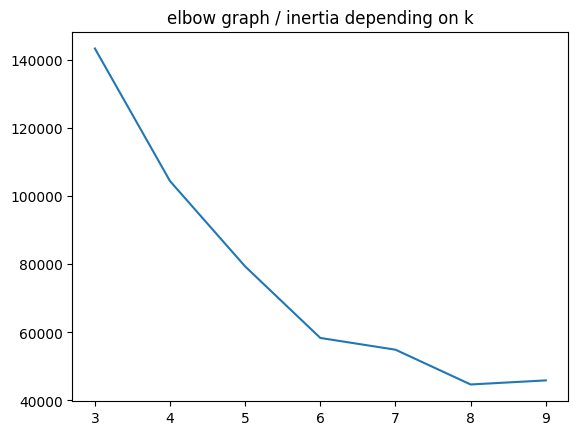

In [4]:
# sns.lineplot(range(3, 10), km_inertias) PHUOCNT
sns.lineplot(x=range(3, 10), y=km_inertias)
plt.title('elbow graph / inertia depending on k')
plt.show()

4. Tìm số cụm tối ưu bằng phương pháp Silhoutte

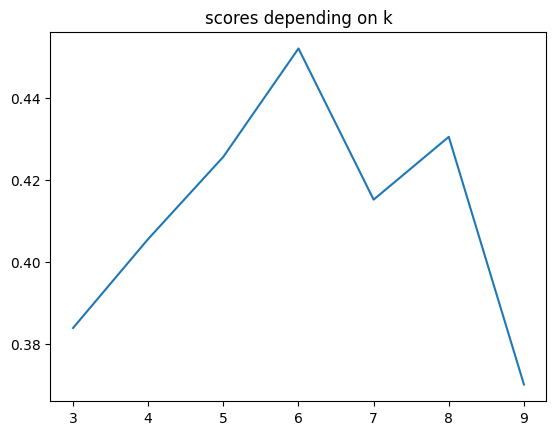

In [5]:
sns.lineplot(x=range(3, 10), y=km_scores)
plt.title('scores depending on k')
plt.show()


4. Gán nhãn cho các mẫu dữ liệu dựa vào mô hình K-Means với số cụm là 6

In [6]:
km = KMeans(n_clusters=6).fit(X)
#Assign the Cluster Labels to the Data
X['Label'] = km.labels_
#Info for each cluster
for k in range(6):
 print(f'Cluster nb : {k}')
 print(X[X.Label == k].describe().iloc[:, 1:-1])
 print('\n\n')


Cluster nb : 0
             Age  Annual Income (k$)  Spending Score (1-100)
count  38.000000           38.000000               38.000000
mean   27.000000           56.657895               49.131579
std     7.032742            9.905708                7.853975
min    18.000000           39.000000               29.000000
25%    21.000000           48.000000               42.000000
50%    26.500000           59.500000               50.000000
75%    31.750000           63.750000               55.000000
max    40.000000           76.000000               61.000000



Cluster nb : 1
             Age  Annual Income (k$)  Spending Score (1-100)
count  35.000000           35.000000               35.000000
mean   41.685714           88.228571               17.285714
std    10.897305           16.367266               10.211215
min    19.000000           71.000000                1.000000
25%    35.000000           77.500000               10.000000
50%    43.000000           85.000000               1

**Bài toán 2**: Thực hiện phân cụm dữ liệu trên tập dữ liệu iris-data. Dữ liệu lấy từ lấy từ
https://www.kaggle.com/code/xvivancos/tutorial-knn-in-the-iris-data-set

**Nhiệm vụ 1**: Phân cụm dữ liệu trên tập dữ liệu iris-data. 

1. Import thư viện và load dữ liệu

In [7]:
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
iris = pd.read_csv("Iris.csv")
iris.drop('Id',inplace=True,axis=1)
X = iris.iloc[:,:-1].values #Set our training data
y = iris.iloc[:,-1].values #We'll use this just for visualization as clustering doesn't require labels
iris.head().style.background_gradient(cmap 
 =sns.cubehelix_palette(as_cmap=True))

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.100000,3.500000,1.400000,0.200000,Iris-setosa
1,4.900000,3.000000,1.400000,0.200000,Iris-setosa
2,4.700000,3.200000,1.300000,0.200000,Iris-setosa
3,4.600000,3.100000,1.500000,0.200000,Iris-setosa
4,5.000000,3.600000,1.400000,0.200000,Iris-setosa


2. EDA và xử lý dữ liệu

In [9]:
# Data Distribution => The Data is perfectly balanced
fig = px.pie(iris, 
'Species',color_discrete_sequence=['#491D8B','#7D3AC1','#EB548C'],title=
'Data Distribution',template='plotly')
fig.show()
# Phân tích biến Sepal-Length với box-plot
fig = px.box(data_frame=iris, x='Species',y='SepalLengthCm',
 color='Species',
 color_discrete_sequence=['#29066B','#7D3AC1','#EB548C'],
 orientation='v')
fig.show()
# Phân tích biến SepalLengthCm với histogram
fig = px.histogram(data_frame=iris, x='SepalLengthCm',
 color='Species',
 color_discrete_sequence=['#491D8B','#7D3AC1','#EB548C'],
 nbins=50)
fig.show()
# Phân tích biến SepalWidth với box plot
fig = px.box(data_frame=iris, x='Species',
 y='SepalWidthCm', color='Species',
 color_discrete_sequence=['#29066B','#7D3AC1','#EB548C'],
 orientation='v')
fig.show()
# Phân tích 2 biến SepalLengthCm và SepalWidthCm
fig = px.scatter(data_frame=iris, x='SepalLengthCm',y='SepalWidthCm'
 ,color='Species',size='PetalLengthCm',
 template='seaborn',
 color_discrete_sequence=['#491D8B','#7D3AC1','#EB548C'],)
fig.update_layout(width=800, height=600,
 xaxis=dict(color="#BF40BF"),
 yaxis=dict(color="#BF40BF"))
fig.show()
# Phân tích 2 biến PetalLengthCm và PetalWidthCm
fig = px.scatter(data_frame=iris, x='PetalLengthCm',y='PetalWidthCm'
 ,color='Species',size='SepalLengthCm',
 template='seaborn',
 color_discrete_sequence=['#491D8B','#7D3AC1','#EB548C'],)
fig.update_layout(width=800, height=600,
 xaxis=dict(color="#BF40BF"),
 yaxis=dict(color="#BF40BF"))
fig.show()

3. Tìm số cluster tối ưu cho mô hình K-Means

In [10]:
sse = []
for i in range(1,9):
 kmeans = KMeans(n_clusters=i , max_iter=300)
 kmeans.fit(X) 
 sse.append(kmeans.inertia_)
fig = px.line(y=sse,template="seaborn",title='Eblow Method')
fig.update_layout(width=800, height=600,
title_font_color="#BF40BF", 
xaxis=dict(color="#BF40BF",title="Clusters"), 
yaxis=dict(color="#BF40BF",title="SSE"))
# Cluster = 3 là số cluster tối ưu cho dữ liệu Iris

4. Xây dựng mô hình K-Means với số cluster tối ưu = 3

In [11]:
kmeans = KMeans(n_clusters = 3, 
 init = 'k-means++', 
 max_iter = 300, n_init = 10, random_state = 0)
clusters = kmeans.fit_predict(X)

5. Trình bày kết quả trực quan các cluster

In [13]:
fig = go.Figure()
fig.add_trace(go.Scatter(
 x=X[clusters == 0, 0], y=X[clusters == 0, 1],
 mode='markers',marker_color='#DB4CB2',name='Iris-setosa'
))
fig.add_trace(go.Scatter(
 x=X[clusters == 1, 0], y=X[clusters == 1, 1],
 mode='markers',marker_color='#c9e9f6',name='Iris-versicolour'
))
fig.add_trace(go.Scatter(
 x=X[clusters == 2, 0], y=X[clusters == 2, 1],
 mode='markers',marker_color='#7D3AC1',name='Iris-virginica'
))
fig.add_trace(go.Scatter(
 x=kmeans.cluster_centers_[:, 0], y= kmeans.cluster_centers_[:,1],
 mode='markers',marker_color='#CAC9CD',marker_symbol=4,
marker_size=13,name='Centroids'
))
fig.update_layout(template='plotly_dark',width=1000, 
height=500,title='Kmean Clustering Results')


### **3.1.3. Bài tập thực hành 1**
Xây dựng mô hình phân cụm K-means trên tập dữ liệu chim cánh cụt. Dữ liệu lấy tại 
https://www.kaggle.com/code/youssefaboelwafa/clustering-penguins-species-k-means-clustering


1. Import thư viện và load dữ liệu


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

penguins = pd.read_csv(r"C:\Users\Admin\OneDrive\Documents\bt ptdl\bt_tuan_ptdl\Lab03 - Thuat toan phan cum\penguins.csv")

2. Eda và xử lý dữ liệu

In [13]:
# Xem vài dòng đầu
print(penguins.head())

# Thông tin tổng quan
print(penguins.info())

# Thống kê mô tả
print(penguins.describe(include='all'))

   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g     sex
0              39.1             18.7              181.0       3750.0    MALE
1              39.5             17.4              186.0       3800.0  FEMALE
2              40.3             18.0              195.0       3250.0  FEMALE
3               NaN              NaN                NaN          NaN     NaN
4              36.7             19.3              193.0       3450.0  FEMALE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB
None
        culmen_length_mm  culmen_depth_m

In [14]:
# Kiểm tra giá trị thiếu (missing values)
penguins.isnull().sum()

culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64

In [15]:
penguins = penguins.dropna(subset=["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g"])


In [16]:
# Kiểm tra trùng lặp và loại bỏ
duplicates = penguins.duplicated().sum()
print(duplicates)
penguins = penguins.drop_duplicates()

0


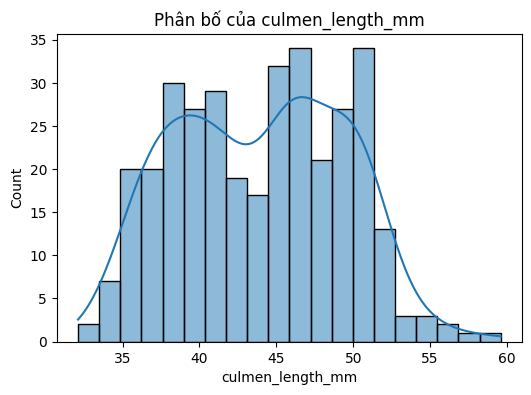

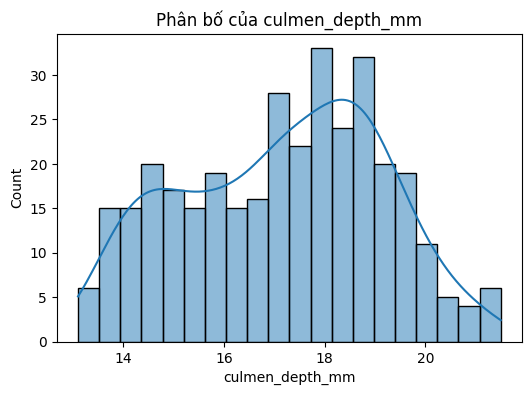

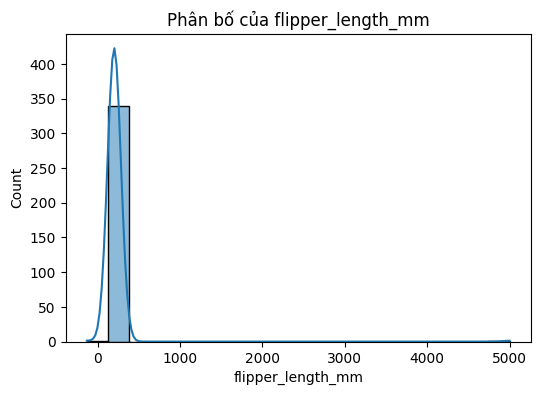

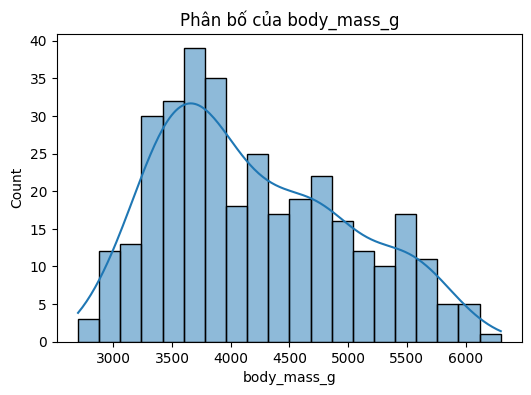

In [17]:
# Phân bố từng biến
numeric_cols = ["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g"]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(penguins[col], kde=True, bins=20)
    plt.title(f"Phân bố của {col}")
    plt.show()

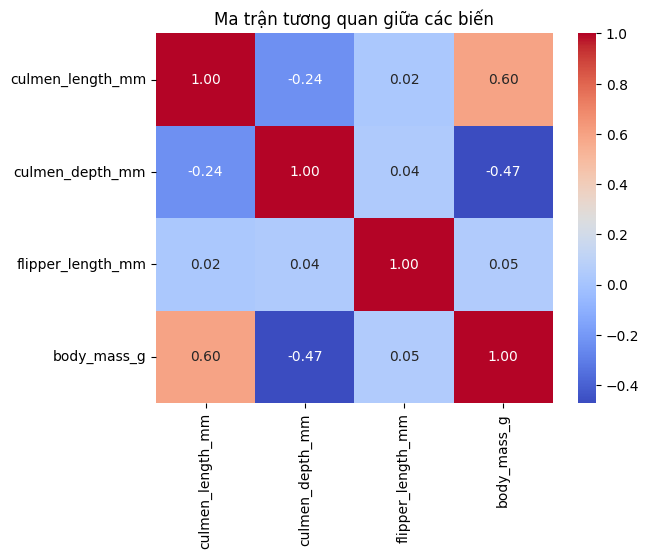

In [18]:
# Mối tương quan giữa các biến
plt.Figure(figsize=(6,4))
sns.heatmap(penguins[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan giữa các biến")
plt.show()

In [19]:
print(penguins.columns)

Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'sex'],
      dtype='object')


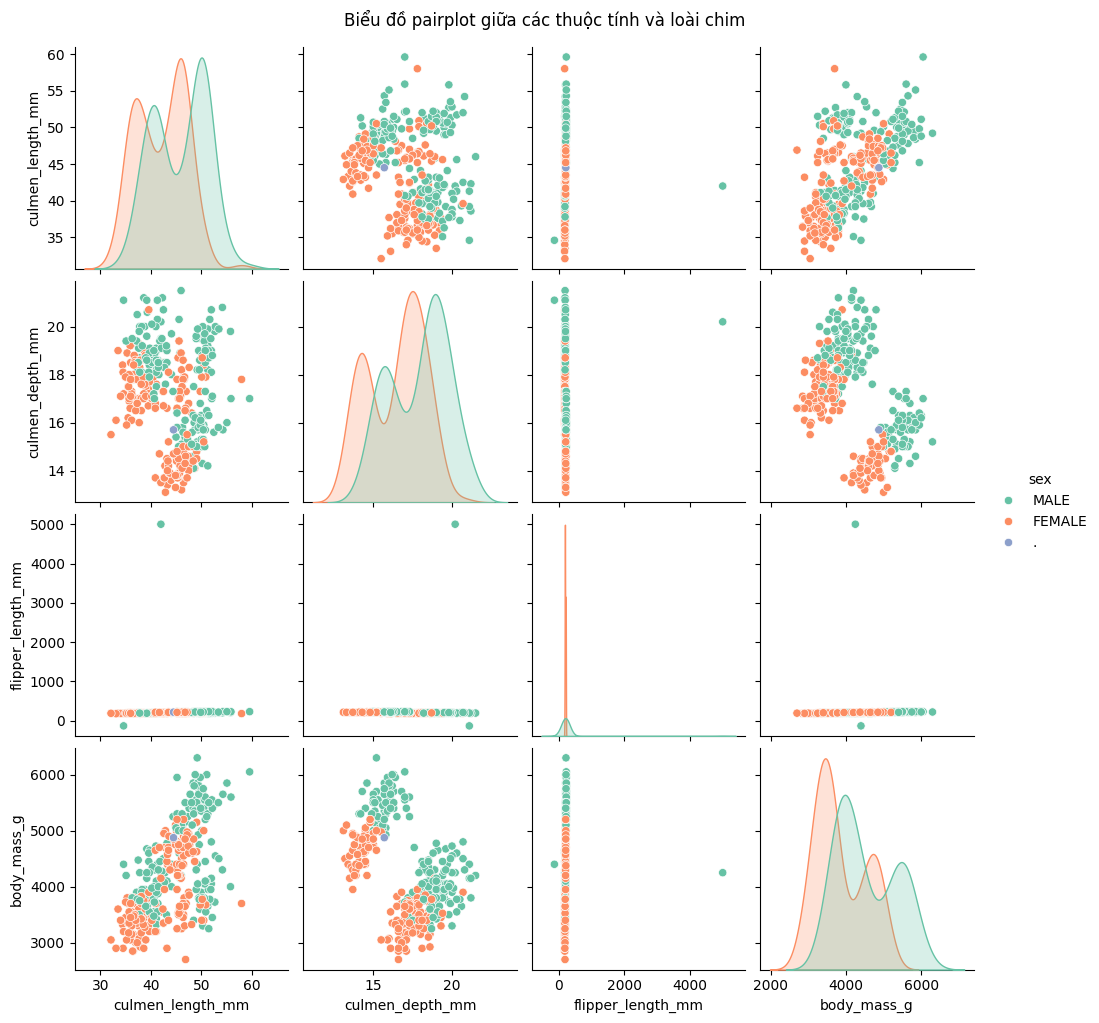

In [20]:
# Biểu đồ so sánh theo giới tính
sns.pairplot(penguins, vars=numeric_cols, hue="sex", diag_kind="kde", palette="Set2")
plt.suptitle("Biểu đồ pairplot giữa các thuộc tính và loài chim", y=1.02)
plt.show()

In [21]:
# Chuẩn hóa dữ liệu (Standardization)
from sklearn.preprocessing import StandardScaler

X = penguins[numeric_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)
X_scaled_df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,-0.884499,0.785449,-0.126893,-0.564142
1,-0.811126,0.126188,-0.107675,-0.501703
2,-0.664380,0.430462,-0.073083,-1.188532
3,-1.324737,1.089724,-0.080771,-0.938776
4,-0.847812,1.748985,-0.092301,-0.689020


3. Tìm số cluster tối ưu cho mô hình K-Means 

In [22]:

sse = [] 
for i in range(1, 11): 
    kmeans = KMeans(n_clusters=i , max_iter=300) 
    kmeans.fit(X)  
    sse.append(kmeans.inertia_) 
fig = px.line(y=sse,template="seaborn",title='Eblow Method') 
fig.update_layout(width=800, height=600, 
title_font_color="#BF40BF",  
xaxis=dict(color="#BF40BF",title="Clusters"),  
yaxis=dict(color="#BF40BF",title="SSE")) 

4. Xây dựng mô hình K-Means với số cluster tối ưu = 3 

In [23]:
kmeans = KMeans(n_clusters = 3,  
        init = 'k-means++',  
        max_iter = 300, n_init = 10, random_state = 0) 
clusters = kmeans.fit_predict(X)

5. Trình bày kết quả trực quan các cluster 

In [25]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=X_scaled[clusters == 0, 0],
    y=X_scaled[clusters == 0, 1],
    mode='markers',
    marker_color='#FD8A8A',
    name='Cluster 0'
))

fig.add_trace(go.Scatter(
    x=X_scaled[clusters == 1, 0],
    y=X_scaled[clusters == 1, 1],
    mode='markers',
    marker_color='#81C6E8',
    name='Cluster 1'
))

fig.add_trace(go.Scatter(
    x=X_scaled[clusters == 2, 0],
    y=X_scaled[clusters == 2, 1],
    mode='markers',
    marker_color='#A084DC',
    name='Cluster 2'
))

# Vẽ centroid
fig.add_trace(go.Scatter(
    x=kmeans.cluster_centers_[:, 0],
    y=kmeans.cluster_centers_[:, 1],
    mode='markers',
    marker_color='#F8F8F8',
    marker_symbol="x",
    marker_size=15,
    name='Centroids'
))

fig.update_layout(
    template='plotly_dark',
    width=1000,
    height=500,
    title='K-Means Clustering Result - Penguins Dataset',
    xaxis_title="Feature 1 (scaled)",
    yaxis_title="Feature 2 (scaled)"
)

fig.show()


### **3.1.4. Bài tập thực hành 2** 
Xây dựng mô hình phân cụm K-means trên tập dữ liệu mua sắm tại siêu thị. Dữ liệu lấy tại 
https://www.kaggle.com/datasets/hellbuoy/online-retail-customer-clustering

1. Import thư viện và load dữ liệu 

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv(r"C:\Users\Admin\OneDrive\Documents\bt ptdl\bt_tuan_ptdl\Lab03 - Thuat toan phan cum\OnlineRetail.csv",  encoding="latin1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


2. EDA và xử lý dữ liệu

In [31]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [32]:
# Loại bỏ dữ liệu thiếu và trùng lặp
df.dropna(subset=['CustomerID'], inplace=True)
df.drop_duplicates(inplace=True)

In [33]:
# Chỉ giữ các giao dịch hợp lệ (Quantity > 0 & UnitPrice > 0)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]


In [34]:
# Tạo biến doanh thu (Total Spend)
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [38]:
# Tạo bảng dữ liệu khách hàng (RFM - Recency, Frequency, Monetary)
# chuyển InvoiceDate về dạng datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed', dayfirst=True)

# tạo TotalAmount
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# tạo Snapshot date - mốc tính RFM
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalAmount': 'sum'                                      # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()



,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


3. Tìm số cluster tối ưu cho mô hình K-Means 

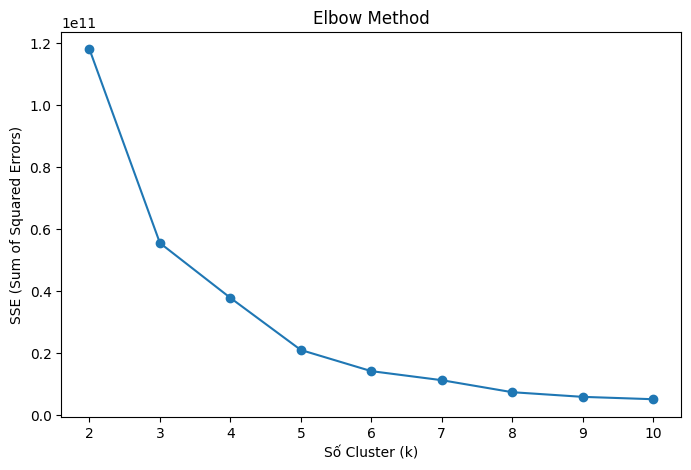

In [39]:
sse = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm[['Recency', 'Frequency', 'Monetary']])
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), sse, marker='o')
plt.title("Elbow Method")
plt.xlabel("Số Cluster (k)")
plt.ylabel("SSE (Sum of Squared Errors)")
plt.show()


4. Xây dựng mô hình K-Means với số cluster tối ưu = 3 

In [40]:
kmeans = KMeans(n_clusters = 3,  
        init = 'k-means++',  
        max_iter = 300, n_init = 10, random_state = 0) 
clusters = kmeans.fit_predict(X) 

5. Trình bày kết quả trực quan các cluster 

In [44]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=X_pca[clusters == 0, 0], y=X_pca[clusters == 0, 1],
    mode='markers', marker_color='#DB4CB2', name='Cluster 0'
))

fig.add_trace(go.Scatter(
    x=X_pca[clusters == 1, 0], y=X_pca[clusters == 1, 1],
    mode='markers', marker_color='#c9e9f6', name='Cluster 1'
))

fig.add_trace(go.Scatter(
    x=X_pca[clusters == 2, 0], y=X_pca[clusters == 2, 1],
    mode='markers', marker_color='#7D3AC1', name='Cluster 2'
))

fig.add_trace(go.Scatter(
    x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1],
    mode='markers', marker_color='#CAC9CD', marker_symbol=4,
    marker_size=13, name='Centroids'
))

fig.update_layout(template='plotly_dark', width=1000,
                  height=500, title='K-Means Clustering - Customer Segmentation')

fig.show()




### **3.2.  GIẢI THUẬT PHÂN CỤM ĐA CẤP**

### **3.2.1. Ôn tập lý thuyết** 

+ Giải thuật phân cụm đa cấp hoạt động như thế nào? Hãy giải thích sự khác biệt giữa phân cụm đa cấp 
hợp nhất (agglomerative) và phân tách (divisive) 
+ Các phương pháp liên kết (linkage) như single linkage, complete linkage, average linkage, và Ward’s 
method khác nhau ra sao? Khi nào nên sử dụng từng loại? 
+ Dendrogram trong phân cụm đa cấp là gì? Làm thế nào để sử dụng nó để chọn số lượng cụm? 
+ Phân cụm đa cấp có thể áp dụng cho dữ liệu phi số (non-numeric data) như thế nào? Hãy giải thích 
+ Viết đoạn code mẫu bằng Python (sử dụng Scikit-learn) để triển khai phân cụm đa cấp hợp nhất 
(agglomerative clustering) không? Hãy mô tả các bước thực hiện 
+ Làm thế nào để vẽ dendrogram trong Python sử dụng thư viện như scipy hoặc matplotlib? Hãy chia sẻ 
một đoạn code mẫu 
+ Các lớp trong gói Scipy hỗ trợ phân cụm đa cấp? và so sánh giữa cách tiếp cận scikit-learn và cách tiếp 
cận sử dụng Scipy 

### **3.2.2. Bài làm mẫu** 

**Bài toán 1: Tìm hiểu một số khái niệm cơ bản của phân cụm đa cấp** 

**Nhiệm vụ 1**: Tìm hiểu một số khái niệm cơ bản của phân cụm đa cấp 

1. Import thư viện, tạo dữ liệu giả (dummy data) và hiển thị dữ liệu

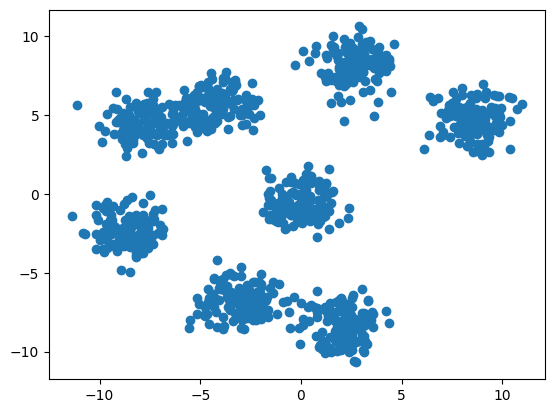

In [48]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster 
from sklearn.datasets import make_blobs 
import matplotlib.pyplot as plt 
%matplotlib inline 
# Generate a random cluster dataset to experiment on. X = coordinate points, y = cluster labels (not needed) 
X, y = make_blobs(n_samples=1000, centers=8, n_features=2, 
random_state=800) 
plt.scatter(X[:,0], X[:,1]) 
plt.show() 

2. Hiển thị ma trận khoảng cách giữa các điểm dữ liệu với điểm trung tâm 

In [49]:
# Generate distance matrix with 'linkage' function 
distances = linkage(X, method="centroid", metric="euclidean") 
print(distances) 

[[5.72000000e+02 7.62000000e+02 7.69412624e-03 2.00000000e+00]
 [3.00000000e+01 1.96000000e+02 8.87881891e-03 2.00000000e+00]
 [5.91000000e+02 8.70000000e+02 1.07476240e-02 2.00000000e+00]
 ...
 [1.98900000e+03 1.99200000e+03 7.81168528e+00 3.75000000e+02]
 [1.99500000e+03 1.99600000e+03 1.02408477e+01 7.50000000e+02]
 [1.99400000e+03 1.99700000e+03 1.20025814e+01 1.00000000e+03]]


3. Vẽ hình dendrogram từ ma trận khoảng cách 

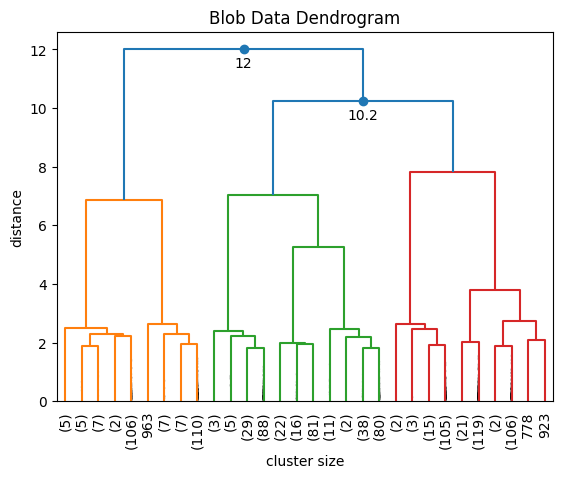

In [51]:
# Take normal dendrogram output and stylize in cleaner way 
def annotated_dendrogram(*args, **kwargs): 
# Standard dendrogram from SciPy 
    scipy_dendro = dendrogram(*args, truncate_mode='lastp',  show_contracted=True,leaf_rotation=90.) 
    plt.title('Blob Data Dendrogram') 
    plt.xlabel('cluster size') 
    plt.ylabel('distance') 
    for i, d, c in zip(scipy_dendro['icoord'], scipy_dendro['dcoord'],  scipy_dendro['color_list']): 
        x = 0.5 * sum(i[1:3]) 
        y = d[1] 
        if y > 10: 
            plt.plot(x, y, 'o', c=c) 
            plt.annotate("%.3g" % y, (x, y), xytext=(0, -5), 
                         textcoords='offset points', 
                         va='top', ha='center') 
    return scipy_dendro 
dn = annotated_dendrogram(distances) 
plt.show() 

4. Vẽ các cụm dữ liệu dựa ma trận khoảng cách và thông tin từ dendrogram với hàm fcluster

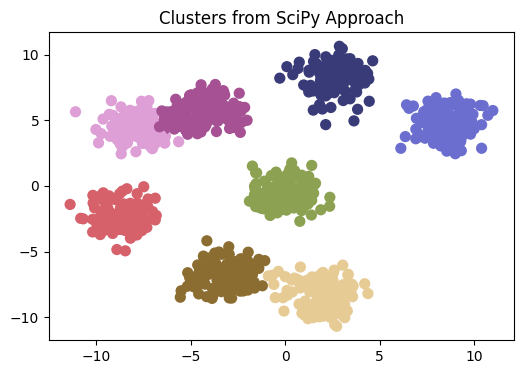

In [52]:
scipy_clusters = fcluster(distances, 3, criterion="distance") 
plt.figure(figsize=(6,4)) 
plt.title("Clusters from SciPy Approach") 
plt.scatter(X[:, 0], X[:, 1], c = scipy_clusters ,s=50, cmap='tab20b') 
plt.show() 

5. Vẽ các cụm dữ liệu với các phương pháp linkage khác nhau 

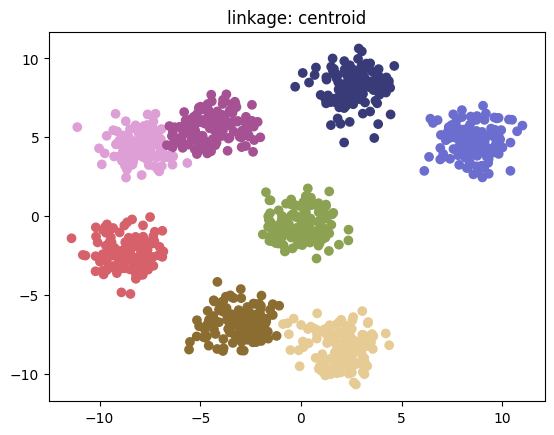

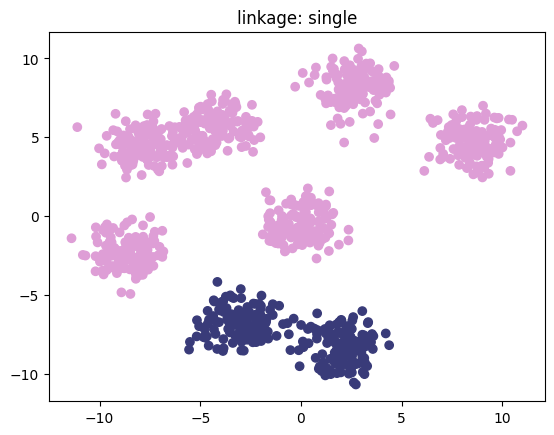

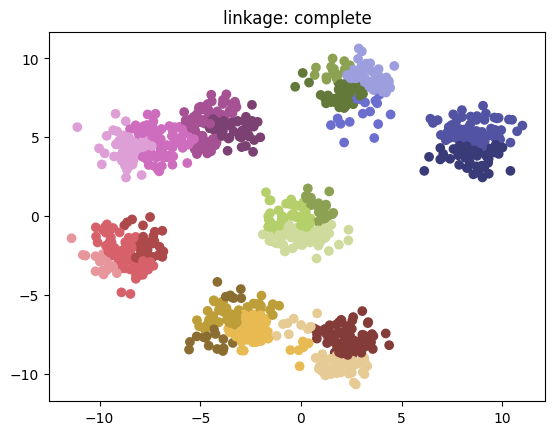

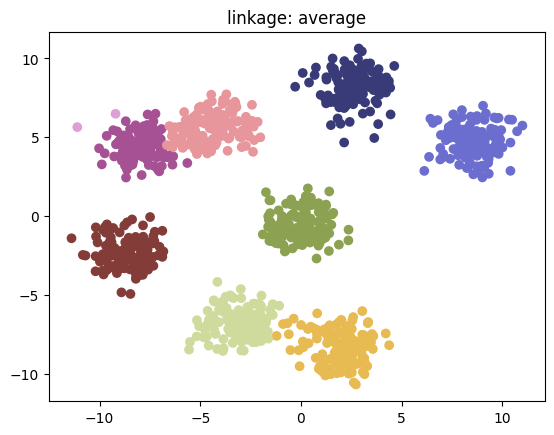

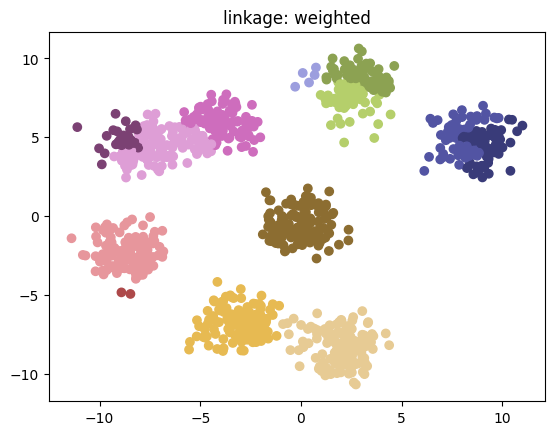

In [53]:
methods = ['centroid', 'single', 'complete', 'average', 'weighted'] 
for method in methods: 
    distances = linkage(X, method=method, metric="euclidean") 
    clusters = fcluster(distances, 3, criterion="distance")  
    plt.title('linkage: ' + method) 
    plt.scatter(X[:,0], X[:,1], c=clusters, cmap='tab20b') 
    plt.show() 

6. Xây dựng mô hình phân cụm đa cấp theo tiếp cận của thư viện scikit-learn 

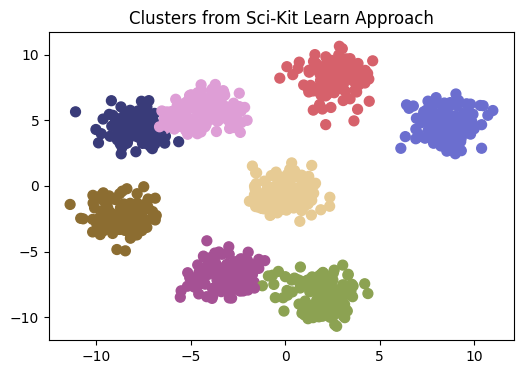

In [54]:
from sklearn.cluster import AgglomerativeClustering 
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster 
 
ac = AgglomerativeClustering(n_clusters = 8, linkage="average") 
#distances = linkage(X, method="centroid", metric="euclidean") 
sklearn_clusters = ac.fit_predict(X) 
scipy_clusters = fcluster(distances, 3, criterion="distance") 
plt.figure(figsize=(6,4)) 
plt.title("Clusters from Sci-Kit Learn Approach") 
plt.scatter(X[:, 0], X[:, 1], c = sklearn_clusters ,s=50, cmap='tab20b') 
plt.show() 

**Bài toán 2: Phân cụm đa cấp trên tập dữ liệu rượu vang. Dữ liệu lấy từ**
 
https://www.kaggle.com/datasets/harrywang/wine-dataset-for-clustering/data 

1. Import & tải dữ liệu rượu vang lên notebook 

In [55]:
from sklearn.cluster import KMeans 
from sklearn.cluster import AgglomerativeClustering 
from sklearn.metrics import silhouette_score 
import pandas as pd 
import matplotlib.pyplot as plt 
wine_df = pd.read_csv(r"C:\Users\Admin\OneDrive\Documents\bt ptdl\bt_tuan_ptdl\Lab03 - Thuat toan phan cum\wine-clustering.csv") 

2. Xây dựng mô hình phân cụm đa cấp theo cách tiếp cận scikit-learn và hiển thị kết quả phân cụm trên 
dữ liệu 

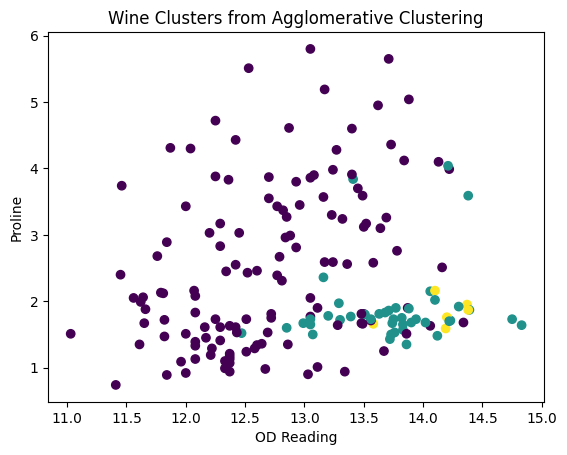

In [56]:
ac = AgglomerativeClustering(3, linkage='average') 
ac_clusters = ac.fit_predict(wine_df) 
# Hiển thị các cụm sau khi phân cấp theo cách tiếp cận của scikit-learn 
plt.scatter(wine_df.values[:,0], wine_df.values[:,1], c=ac_clusters) 
plt.title("Wine Clusters from Agglomerative Clustering") 
plt.xlabel("OD Reading") 
plt.ylabel("Proline") 
plt.show() 

3. Phân cụm sử dụng K-Means và so sánh với kết quả phân cụm đa cấp 

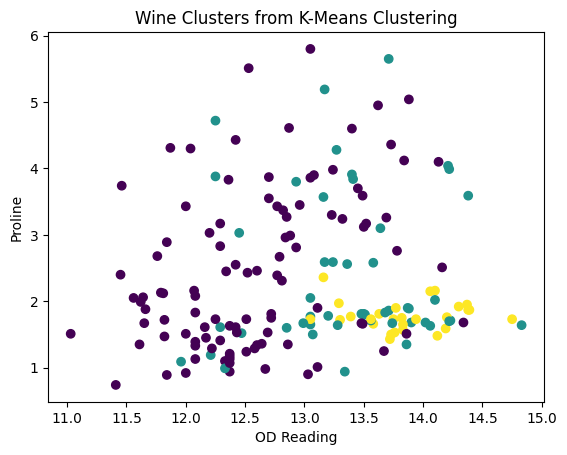

In [57]:
km = KMeans(3) 
km_clusters = km.fit_predict(wine_df) 
# Hiển thị kết quả sau khi phân cụm K-mean 
plt.scatter(wine_df.values[:,0], wine_df.values[:,1], c=km_clusters) 
plt.title("Wine Clusters from K-Means Clustering") 
plt.xlabel("OD Reading") 
plt.ylabel("Proline") 
plt.show()

4. So sánh kết quả phân cụm của 2 mô hình với phương pháp tính Silhouette 

In [58]:
# Calculate Silhouette Scores 
print("Silhouette Scores for Wine Dataset:\n") 
print("K-Means Clustering: ", silhouette_score(wine_df, km_clusters)) 
print("Agg Clustering: ", silhouette_score(wine_df, ac_clusters)) 

Silhouette Scores for Wine Dataset:

K-Means Clustering:  0.5595823478987215
Agg Clustering:  0.6100753288756409


### **3.2.3. Bài tập thực hành 1** 

Xây dựng mô hình phân cụm đa cấp trên tập dữ liệu chim cánh cụt. Dữ liệu lấy tại 

https://www.kaggle.com/code/youssefaboelwafa/clustering-penguins-species-k-means-clustering 

1. Import & tải dữ liệu chim cánh cụt lên notebook 

In [62]:
from sklearn.cluster import KMeans 
from sklearn.cluster import AgglomerativeClustering 
from sklearn.metrics import silhouette_score 
import pandas as pd 
import matplotlib.pyplot as plt 
pen_df = pd.read_csv(r"C:\Users\Admin\OneDrive\Documents\bt ptdl\bt_tuan_ptdl\Lab03 - Thuat toan phan cum\penguins.csv") 

2. Xây dựng mô hình phân cụm đa cấp theo cách tiếp cận scikit-learn và hiển thị kết quả phân cụm trên 
dữ liệu 

In [67]:
from sklearn.preprocessing import LabelEncoder

# Copy data để xử lý
df = pen_df.copy()

# Encode các cột dạng chuỗi
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = LabelEncoder().fit_transform(df[col])
df = df.dropna()
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,2
1,39.5,17.4,186.0,3800.0,1
2,40.3,18.0,195.0,3250.0,1
4,36.7,19.3,193.0,3450.0,1
5,39.3,20.6,190.0,3650.0,2


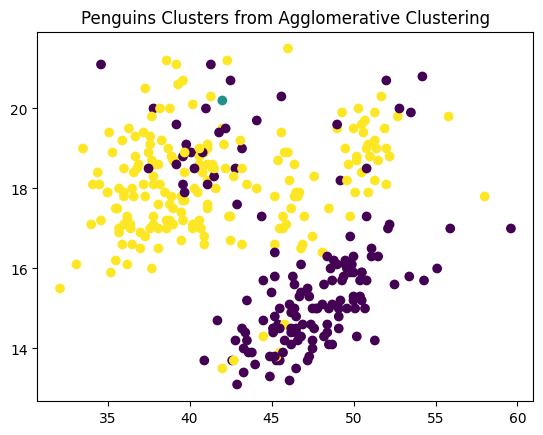

In [68]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

ac = AgglomerativeClustering(n_clusters=3, linkage='average')
ac_clusters = ac.fit_predict(df)

plt.scatter(df.values[:,0], df.values[:,1], c=ac_clusters)
plt.title("Penguins Clusters from Agglomerative Clustering")
plt.show()


3. Phân cụm sử dụng K-Means và so sánh với kết quả phân cụm đa cấp 

In [83]:
pen_df = pd.DataFrame(pen_df)



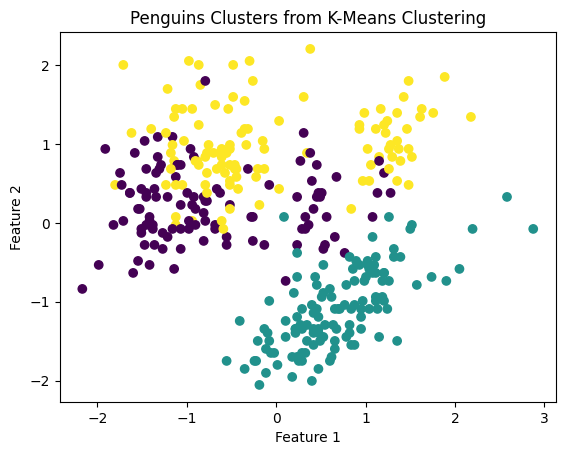

In [84]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

# Standardize dữ liệu (giả sử pen_df gốc là dataframe chứa các cột số)
scaler = StandardScaler()
pen_df = scaler.fit_transform(pen_df)

# Chuyển lại thành DataFrame để dùng .values
pen_df = pd.DataFrame(pen_df)

# K-Means clustering
km = KMeans(n_clusters=3, random_state=0)
km_clusters = km.fit_predict(pen_df)

# Plot kết quả
plt.scatter(pen_df.values[:,0], pen_df.values[:,1], c=km_clusters)
plt.title("Penguins Clusters from K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


4. So sánh kết quả phân cụm của 2 mô hình với phương pháp tính Silhouette 

In [85]:
# Calculate Silhouette Scores 
print("Silhouette Scores for Wine Dataset:\n") 
print("K-Means Clustering: ", silhouette_score(pen_df, km_clusters)) 
print("Agg Clustering: ", silhouette_score(pen_df, ac_clusters))

Silhouette Scores for Wine Dataset:

K-Means Clustering:  0.4231195054458764
Agg Clustering:  0.305932264290194


### **3.2.4. Bài tập thực hành 2** 
Xây dựng mô hình phân cụm đa cấp trên tập dữ liệu mua sắm tại siêu thị. Dữ liệu lấy tại 

https://www.kaggle.com/datasets/hellbuoy/online-retail-customer-clustering 

1. Import & tải dữ liệu lên notebook 

In [7]:
from sklearn.cluster import KMeans 
from sklearn.cluster import AgglomerativeClustering 
from sklearn.metrics import silhouette_score 
import pandas as pd 
import matplotlib.pyplot as plt 
df = pd.read_csv(r"C:\Users\Admin\OneDrive\Documents\bt ptdl\bt_tuan_ptdl\Lab03 - Thuat toan phan cum\OnlineRetail.csv", encoding='latin1')

2. Xây dựng mô hình phân cụm đa cấp theo cách tiếp cận scikit-learn và hiển thị kết quả phân cụm trên 
dữ liệu 

In [10]:
# Loại bỏ đơn trả hàng (credit note)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Xóa CustomerID bị thiếu
df = df.dropna(subset=['CustomerID'])

# Tạo tổng giá trị cho mỗi dòng
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Chuyển ngày tháng
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True, errors='coerce')


In [11]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
}).reset_index()

rfm_df.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm_df.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,182,4310.00
2,12348.0,75,31,1797.24
3,12349.0,19,73,1757.55
4,12350.0,310,17,334.40


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary']])


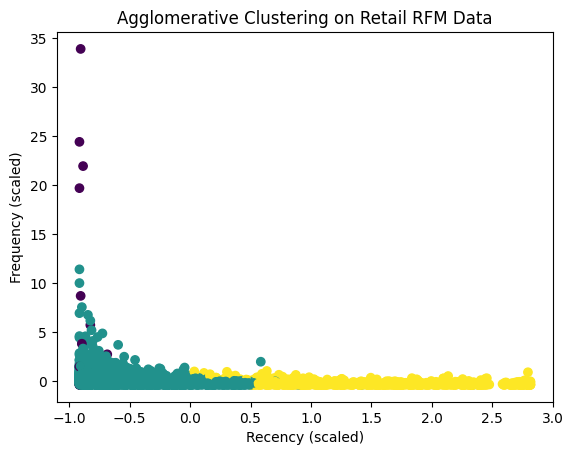

In [13]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

ac = AgglomerativeClustering(n_clusters=3, linkage='ward')
ac_labels = ac.fit_predict(rfm_scaled)

plt.scatter(rfm_scaled[:, 0], rfm_scaled[:, 1], c=ac_labels)
plt.title("Agglomerative Clustering on Retail RFM Data")
plt.xlabel("Recency (scaled)")
plt.ylabel("Frequency (scaled)")
plt.show()

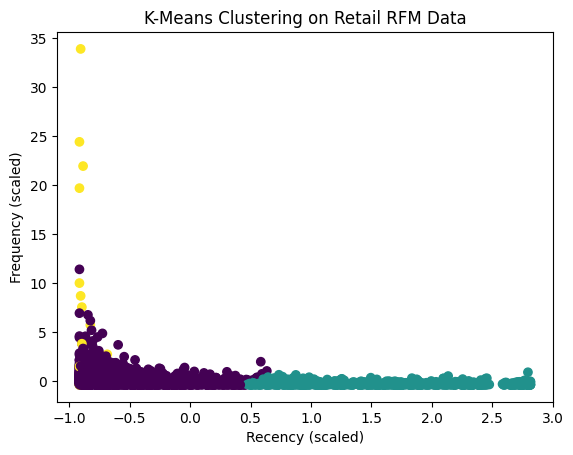

In [14]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
km_labels = kmeans.fit_predict(rfm_scaled)

plt.scatter(rfm_scaled[:, 0], rfm_scaled[:, 1], c=km_labels)
plt.title("K-Means Clustering on Retail RFM Data")
plt.xlabel("Recency (scaled)")
plt.ylabel("Frequency (scaled)")
plt.show()


4. So sánh kết quả phân cụm của 2 mô hình với phương pháp tính Silhouette

In [15]:
from sklearn.metrics import silhouette_score

sil_ac = silhouette_score(rfm_scaled, ac_labels)
sil_km = silhouette_score(rfm_scaled, km_labels)

print("Silhouette Agglomerative:", sil_ac)
print("Silhouette KMeans:", sil_km)

Silhouette Agglomerative: 0.5946963269719893
Silhouette KMeans: 0.6020142101419289


### **D. TÓM TẮT**

Với 2 phần là phân cụm với K-means và phân cụm đa cấp được trình bày trong chương đã phần nào giúp
sinh viên có thể tiến hình triển khai bài toán phân cụm trên một số tập dữ liệu cơ bản.
Với việc thực hành giải quyết các bài tập trên lớp và các bài tập ở nhà giúp sinh viên hiểu rõ hơn các khái
niệm lý thuyết đã học và áp dụng tốt vào việc giải quyết các bài toán phân cụm trong thực tế.